# Portfolio Stress Testing

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drsamirasaf-creator/ge-lav-companion-code/blob/main/notebooks/07_stress_scenarios.ipynb)

> **Colab users:** the first cell auto-installs `gelav`. Local users can skip it.

*Course sessions: S18 (Platform architecture)*

---

Stress testing applies an L-shock scenario to a portfolio and tracks
mark-to-market, exit decisions, and P&L paths over the scenario duration.

Standard scenarios (Session 18, Table 18.4):

| Scenario | L shock | Duration | Use case |
|---|---|---|---|
| Mild downturn | 0 → -0.5 | 12 mo | Tactical rebalance |
| Recession | 0 → -1.0 | 24 mo | Liquidity planning |
| GFC-equivalent | 0 → -1.5 | 18 mo | Tail risk · capital adequacy |
| COVID-like rapid | 0 → -1.2 → recovery | 6 mo | Whipsaw |
| Persistent low | -0.5 sustained | 60 mo | Long stagnation |
| Reverse stress | 0 → +1.0 | 12 mo | Capital release |

This notebook runs all six scenarios on a sample portfolio and reports
summary statistics.

In [1]:
# Auto-install gelav if running in Colab
import sys
if 'google.colab' in sys.modules:
    !pip install -q git+https://github.com/drsamirasaf-creator/ge-lav-companion-code.git

## 1. Define a sample portfolio

A mid-sized pension fund's PE allocation: five funds across vintages and
strategies, total $400M NAV.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gelav.stress import (StressScenario, standard_scenarios,
                          run_stress, summarize_stress)
from gelav.hjb import solve_hjb, exit_boundary

plt.rcParams['figure.dpi'] = 110
NAVY = '#1E3A5F'; GOLD = '#C89B3C'; RED = '#C0392B'; GREEN = '#276F4E'

portfolio = [
    {"name": "Buyout 2020",   "NAV": 120, "T_remaining": 6.0},
    {"name": "VC 2021",       "NAV":  80, "T_remaining": 8.0},
    {"name": "Infra 2019",    "NAV":  90, "T_remaining": 5.0},
    {"name": "Growth 2022",   "NAV":  60, "T_remaining": 7.0},
    {"name": "Private credit 2023", "NAV": 50, "T_remaining": 3.0},
]

pd.DataFrame(portfolio).style.format({"NAV": "${:.0f}M",
                                       "T_remaining": "{:.1f} yrs"})

,name,NAV,T_remaining
0,Buyout 2020,$120M,6.0 yrs
1,VC 2021,$80M,8.0 yrs
2,Infra 2019,$90M,5.0 yrs
3,Growth 2022,$60M,7.0 yrs
4,Private credit 2023,$50M,3.0 yrs


## 2. Build an L*(t) function from the HJB solver

We pass `exit_boundary_fn` to `run_stress` so the runner can flag funds
that should exit at each step of the scenario.

In [3]:
hjb_result = solve_hjb(kappa=0.45, sigma=0.32, L_bar=1.0, r=0.08,
                       T_fund=10.0, n_L=80, n_t=80)
t_rem_grid, L_star_grid = exit_boundary(hjb_result)

# Build interpolator
from scipy.interpolate import interp1d
exit_fn = interp1d(t_rem_grid, L_star_grid, kind='linear',
                   bounds_error=False, fill_value=(L_star_grid[0], L_star_grid[-1]))

# Quick sanity check
for t_rem in [10.0, 7.0, 5.0, 3.0, 1.0, 0.5]:
    print(f'  L*(T-t = {t_rem:>4.1f} yrs) = {exit_fn(t_rem):.3f}')

  L*(T-t = 10.0 yrs) = 0.949
  L*(T-t =  7.0 yrs) = 0.949
  L*(T-t =  5.0 yrs) = 0.949
  L*(T-t =  3.0 yrs) = 0.949
  L*(T-t =  1.0 yrs) = 0.949
  L*(T-t =  0.5 yrs) = 0.949


## 3. Run all 6 standard scenarios

In [4]:
scenarios = standard_scenarios()
results = {}
summaries = []
for key, scn in scenarios.items():
    res = run_stress(portfolio, scn, exit_boundary_fn=exit_fn)
    results[key] = res
    summaries.append(summarize_stress(res))

df_summary = pd.DataFrame(summaries)
df_summary.style.format({
    "initial_value": "${:.1f}M",
    "final_value": "${:.1f}M",
    "max_drawdown_pct": "{:+.1f}%",
    "recovery_pct": "{:+.1f}%",
})

,scenario_name,initial_value,final_value,max_drawdown_pct,recovery_pct,n_funds_exiting,duration_months
0,Mild downturn,$400.0M,$344.9M,-13.8%,+0.0%,5,12
1,Recession,$400.0M,$329.4M,-17.7%,+0.0%,5,24
2,GFC-equivalent,$400.0M,$292.5M,-26.9%,+0.0%,5,18
3,COVID-like rapid,$400.0M,$349.8M,-24.9%,+12.3%,5,6
4,Persistent low,$400.0M,$375.7M,-14.5%,+8.4%,5,60
5,Reverse stress,$400.0M,$364.0M,-10.9%,+1.9%,5,12


## 4. Visualize: total portfolio MTM across all scenarios

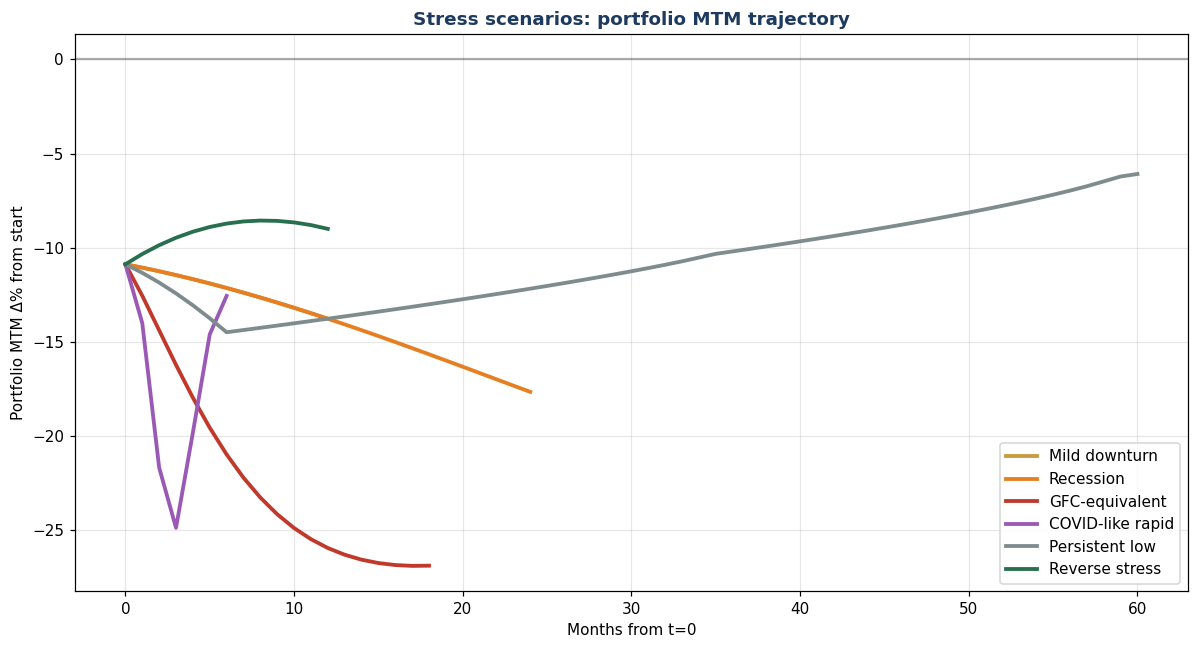

In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
colors = {"mild": GOLD, "recession": '#E67E22', "gfc": RED,
          "covid": '#9B59B6', "stagnation": '#7F8C8D', "reverse": GREEN}

for key, res in results.items():
    months = np.arange(len(res['total_mtm']))
    pct = (res['total_mtm'] / res['initial_NAV'] - 1) * 100
    ax.plot(months, pct, lw=2.5, label=res['scenario'].name,
            color=colors.get(key, NAVY))

ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('Months from t=0'); ax.set_ylabel('Portfolio MTM Δ% from start')
ax.set_title('Stress scenarios: portfolio MTM trajectory',
             color=NAVY, weight='bold')
ax.legend(loc='lower right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 5. Drill down: which funds would exit under GFC?

Track which funds cross L*(t) at any point during the GFC scenario.

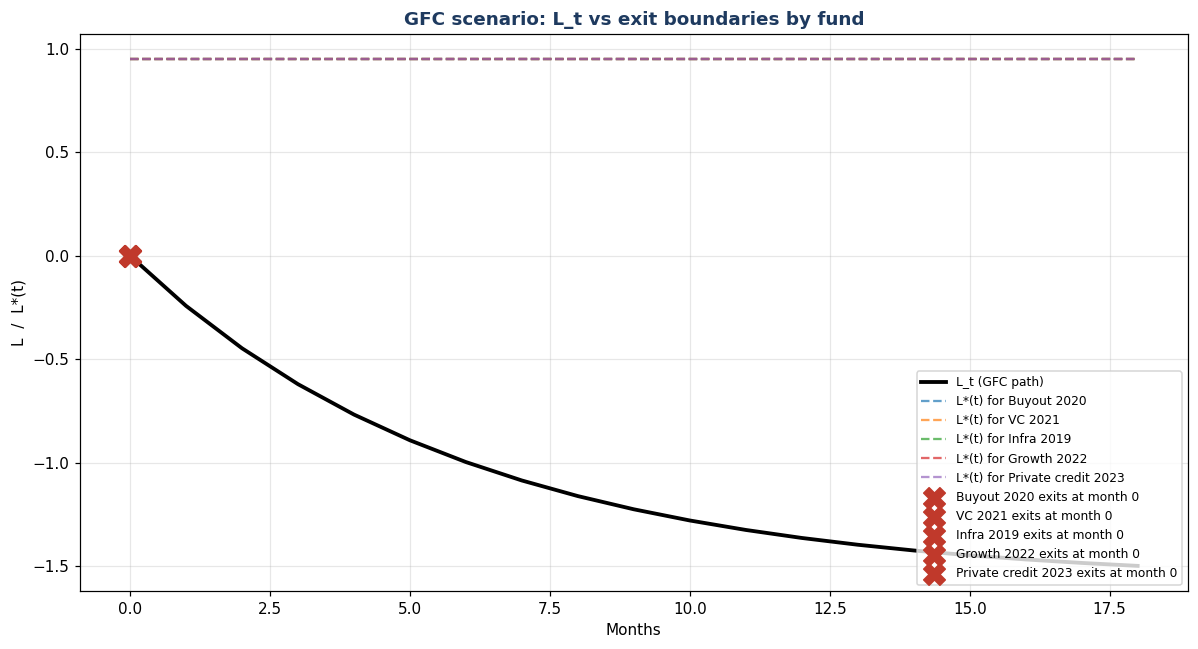


Exit summary (which funds would exit at any point):
  Buyout 2020: EXIT triggered at month 0 (L=0.00)
  VC 2021: EXIT triggered at month 0 (L=0.00)
  Infra 2019: EXIT triggered at month 0 (L=0.00)
  Growth 2022: EXIT triggered at month 0 (L=0.00)
  Private credit 2023: EXIT triggered at month 0 (L=0.00)


In [6]:
gfc = results['gfc']
fig, ax = plt.subplots(figsize=(11, 6))

months = np.arange(len(gfc['L_path']))
ax.plot(months, gfc['L_path'], 'k-', lw=2.5, label='L_t (GFC path)')

# Plot per-fund L*(t) under decreasing T_remaining
for j, fund in enumerate(portfolio):
    T_rem_path = np.maximum(0.1, fund['T_remaining'] - months / 12.0)
    L_star_path = exit_fn(T_rem_path)
    ax.plot(months, L_star_path, '--', alpha=0.7,
            label=f'L*(t) for {fund["name"]}')

# Mark exits
exits = gfc['exit_decisions']
for j, fund in enumerate(portfolio):
    exit_months = np.where(exits[j])[0]
    if len(exit_months) > 0:
        first_exit = exit_months[0]
        ax.scatter(first_exit, gfc['L_path'][first_exit], s=200,
                   marker='X', color=RED, zorder=10,
                   label=f'{fund["name"]} exits at month {first_exit}'
                          if j == 0 or len(exit_months) > 0 else None)

ax.set_xlabel('Months'); ax.set_ylabel('L  /  L*(t)')
ax.set_title('GFC scenario: L_t vs exit boundaries by fund',
             color=NAVY, weight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print('\nExit summary (which funds would exit at any point):')
for j, fund in enumerate(portfolio):
    exits_j = exits[j]
    if exits_j.any():
        first = np.argmax(exits_j)
        print(f'  {fund["name"]}: EXIT triggered at month {first} (L={gfc["L_path"][first]:.2f})')
    else:
        print(f'  {fund["name"]}: HOLD throughout (never crosses L*)')

## 6. Custom scenario: build your own

Suppose we want to test a "stagflation" path: L slowly drifts to -0.8 over
36 months and stays there. Easy to construct.

{'scenario_name': 'Stagflation', 'initial_value': 400.0, 'final_value': 348.73291549214235, 'max_drawdown_pct': -17.656331884782034, 'recovery_pct': 4.8395607578176225, 'n_funds_exiting': 5, 'duration_months': 36}


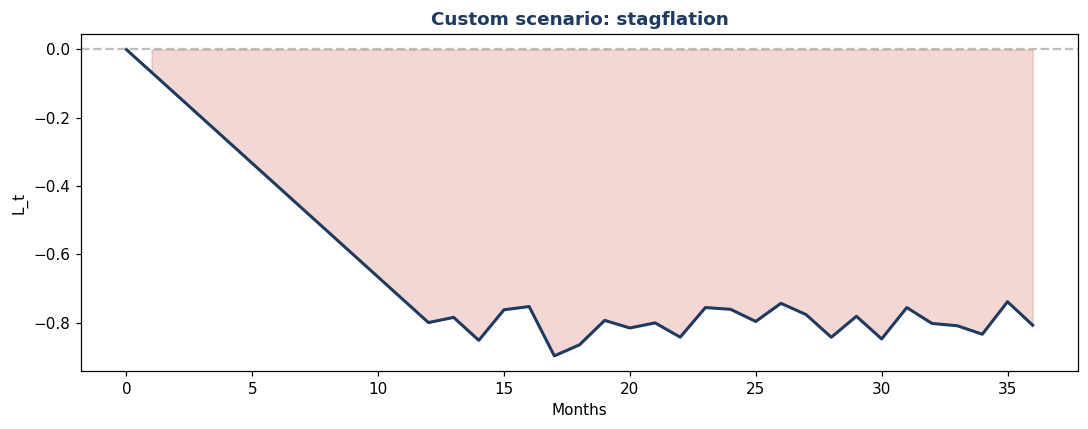

In [7]:
L_stagflation = np.concatenate([
    np.linspace(0, -0.8, 13),       # months 0-12: drift to -0.8
    np.full(24, -0.8) + np.random.default_rng(42).normal(0, 0.05, 24),  # months 13-36: jitter
])
stagflation = StressScenario.custom("Stagflation", L_stagflation,
                                     description="L drifts to -0.8 and stays")
res_stag = run_stress(portfolio, stagflation, exit_boundary_fn=exit_fn)
print(summarize_stress(res_stag))

fig, ax = plt.subplots(figsize=(10, 4))
months = np.arange(len(res_stag['L_path']))
ax.plot(months, res_stag['L_path'], color=NAVY, lw=2)
ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax.fill_between(months, 0, res_stag['L_path'],
                where=res_stag['L_path'] < 0, alpha=0.2, color=RED)
ax.set_xlabel('Months'); ax.set_ylabel('L_t')
ax.set_title('Custom scenario: stagflation', color=NAVY, weight='bold')
plt.tight_layout(); plt.show()

## Suggested exercises

1. **(easy)** Modify the portfolio to be VC-heavy (replace buyout with VC).
   How does this change drawdowns under each scenario?

2. **(medium)** Generate **100 stochastic OU realizations** as scenarios
   (use `StressScenario.stochastic_ou` with different seeds) and report
   the distribution of max drawdowns. Where does the GFC scenario sit?

3. **(hard)** Combine notebooks 03 and 07: in a Monte Carlo sense,
   evaluate the **regret** from using DCF vs GE-LAV decision rules.
   Report the average difference in realized P&L over 1000 OU paths.